В этом задании вам предстоит дообучить трансформерную модель для NER-задачи в различных форматах:

*Обучите NER-модель*
1. Загрузите набор данных Collection5 - **1 балл**
2. Разбейте набор данных на train/test части
3. Дообучите модель rubert-tiny2 на train-части корпуса для решения NER-задачи, сделайте замеры качества NER-метрик до и после дообучения - **2 балла**

In [1]:
%%capture
!wget http://www.labinform.ru/pub/named_entities/collection5.zip
!unzip collection5.zip
!rm collection5.zip

In [2]:
%%capture
!pip install corus razdel evaluate datasets seqeval

In [3]:
%%capture
!pip install transformers

In [4]:
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
from collections import defaultdict
from nltk.tokenize import word_tokenize
from datasets import Dataset
import matplotlib.pyplot as plt


from transformers import DataCollatorForTokenClassification, AutoTokenizer, AutoModelForTokenClassification
from transformers import Trainer, TrainingArguments

from seqeval.metrics import classification_report, precision_score, recall_score, f1_score

import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
import random
import torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)


Загружаем данные

In [6]:
DATA_DIR = Path("/content/Collection5")  # Путь к распакованной папке

def parse_ann_file(ann_path):
    entities = []
    with open(ann_path, encoding='utf-8') as f:
        for line in f:
            if not line.startswith("T"):
                continue
            parts = line.strip().split('\t')
            if len(parts) < 3:
                continue
            tag_info = parts[1].split()
            entity_type = tag_info[0]
            start = int(tag_info[1])
            end = int(tag_info[-1])  # может быть start end или start1 end1;start2 end2
            entities.append({"start": start, "end": end, "type": entity_type})
    return entities

def align_tokens_with_entities(text, entities):
    tokens = word_tokenize(text)
    offsets = []
    current = 0
    for token in tokens:
        start = text.find(token, current)
        offsets.append((start, start + len(token)))
        current = start + len(token)

    tags = ["O"] * len(tokens)
    for ent in entities:
        for i, (start, end) in enumerate(offsets):
            if ent["start"] <= start < ent["end"]:
                if tags[i] == "O":
                    prefix = "B" if start == ent["start"] else "I"
                    tags[i] = f"{prefix}-{ent['type']}"
    return tokens, tags

def load_dataset_from_brat(path):
    data = []
    for file in os.listdir(path):
        if file.endswith(".txt"):
            base = file[:-4]
            txt_path = path / f"{base}.txt"
            ann_path = path / f"{base}.ann"
            if not ann_path.exists():
                continue
            with open(txt_path, encoding='utf-8') as f:
                text = f.read()
            entities = parse_ann_file(ann_path)
            tokens, tags = align_tokens_with_entities(text, entities)
            data.append({"tokens": tokens, "ner_tags": tags})
    return data

data = load_dataset_from_brat(DATA_DIR)

# Построим список всех уникальных тегов и преобразуем в id
unique_tags = sorted({tag for item in data for tag in item["ner_tags"]})
tag2id = {tag: i for i, tag in enumerate(unique_tags)}
id2tag = {i: tag for tag, i in tag2id.items()}

# Преобразуем разметку в числовую
for item in data:
    item["ner_tags"] = [tag2id[tag] for tag in item["ner_tags"]]

dataset = Dataset.from_list(data)
dataset = dataset.train_test_split(test_size=0.2, seed=42)


Список уникальных тэгов

In [ ]:
unique_tags

['B-GEOPOLIT',
 'B-LOC',
 'B-MEDIA',
 'B-ORG',
 'B-PER',
 'I-GEOPOLIT',
 'I-LOC',
 'I-MEDIA',
 'I-ORG',
 'I-PER',
 'O']

Загрузим токенизатор и модель

In [7]:
model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(
    model_name, num_labels=len(id2tag), id2label=id2tag, label2id=tag2id
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Коллатор нужен для добавления паддингов и обработки меток

In [10]:
data_collator = DataCollatorForTokenClassification(tokenizer)

Функция подсчета метрик

In [8]:
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Преобразуем индексы в имена тегов, убирая -100
    true_labels = [
        [id2tag[label_id] for label_id in label if label_id != -100]
        for label in labels
    ]
    true_predictions = [
        [id2tag[pred_id] for pred_id, label_id in zip(prediction, label) if label_id != -100]
        for prediction, label in zip(predictions, labels)
    ]

    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }


In [ ]:
lengths = [len(x["tokens"]) for x in dataset["train"]]
print(f"Средняя длина: {sum(lengths) / len(lengths):.2f}")

Средняя длина: 261.96


Обработка текстов

In [11]:
def tokenize_and_align_labels(example):
    tokenized_inputs = tokenizer(
        example["tokens"],
        truncation=True,
        is_split_into_words=True,
        return_offsets_mapping=True,
        padding=True,
        max_length=128,  # Длина, при необходимости можно подкорректировать
    )

    labels = []
    word_ids = tokenized_inputs.word_ids()
    previous_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)  # Пропускаем специальные токены
        elif word_idx != previous_word_idx:
            labels.append(example["ner_tags"][word_idx])
        else:
            labels.append(example["ner_tags"][word_idx])  # или -100, если хочешь игнорировать subword-и

        previous_word_idx = word_idx

    tokenized_inputs["labels"] = labels
    tokenized_inputs.pop("offset_mapping")

    return tokenized_inputs

# Применяем токенизацию ко всем данным
tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=False,
    remove_columns=["tokens", "ner_tags"]
)

# Параметры обучения
training_args = TrainingArguments(
    output_dir="./ner_model",
    num_train_epochs=20,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    save_steps=500,
    fp16=True,
    remove_unused_columns=False,  # Не игнорируем неиспользуемые колонки
    push_to_hub=False,
    run_name="ner",
    logging_steps=100,
)

# Создаем Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

<ipython-input-11-7e33964c2486>:53: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Метрики до обучения

In [11]:
print("Before fine-tuning:")
metrics_before = trainer.evaluate()
metrics_before

Before fine-tuning:


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: polina-shpineva (polina-shpineva-itmo-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


{'eval_loss': 2.643545627593994,
 'eval_model_preparation_time': 0.0018,
 'eval_precision': 0.010052819901175668,
 'eval_recall': 0.04256854256854257,
 'eval_f1': 0.016264645072363887,
 'eval_runtime': 1.6947,
 'eval_samples_per_second': 118.018,
 'eval_steps_per_second': 4.131}

Обучение

In [12]:
trainer.train()

Step,Training Loss
100,0.899800
200,0.429300
300,0.318400
400,0.271100
500,0.251400


TrainOutput(global_step=500, training_loss=0.43399337768554686, metrics={'train_runtime': 38.9096, 'train_samples_per_second': 411.209, 'train_steps_per_second': 12.85, 'total_flos': 28331446272000.0, 'train_loss': 0.43399337768554686, 'epoch': 20.0})

Метрики после обучения, как видно, метрики точности выросли, лосс упал, как и предполагалось

In [13]:
print("After fine-tuning:")
metrics_after = trainer.evaluate()
metrics_after

After fine-tuning:


{'eval_loss': 0.3017076551914215,
 'eval_model_preparation_time': 0.0018,
 'eval_precision': 0.5308689024390244,
 'eval_recall': 0.5025252525252525,
 'eval_f1': 0.5163083765752409,
 'eval_runtime': 0.5095,
 'eval_samples_per_second': 392.568,
 'eval_steps_per_second': 13.74,
 'epoch': 20.0}

In [14]:
trainer.save_model("./ner_rubert_pretrained_20epochs")

Попробуйте улучшить качество модели следующими способами:

1. Предварительно дообучите на train-части в MLM режиме, а потом дообучите на NER-задачу - 2 балла
2. Сгенерируйте синтетическую разметку подходящего, на ваш взгляд, новостного корпуса большой и умной моделью для русскоязычного NER, а затем использовав ее для дообучения rubert-tiny2 вместе с основным набором данных - 2 балла


### MLM

Подготовка данных для задачи MLM

In [12]:
from transformers import DataCollatorForLanguageModeling

# Вытаскиваем чистые тексты
def get_train_texts(example):
    return {"text": " ".join(example["tokens"])}

mlm_dataset = dataset["train"].map(get_train_texts)

tokenized_mlm_dataset = mlm_dataset.map(
    lambda x: tokenizer(x["text"], truncation=True, padding="max_length", max_length=128),
    batched=True,
    remove_columns=mlm_dataset.column_names
)

# MLM требует специальный data_collator
mlm_data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [17]:
print(tokenized_mlm_dataset[0])

{'input_ids': [2, 80747, 63854, 24159, 9906, 57978, 603, 2631, 35293, 300, 18, 292, 2593, 2702, 603, 54446, 9252, 57978, 603, 16, 1977, 31762, 11641, 39399, 16, 17134, 34935, 16, 1046, 27654, 43582, 24159, 23790, 10798, 6744, 35293, 22591, 63010, 5747, 292, 2593, 2702, 603, 16, 312, 769, 16414, 17, 14791, 57283, 10138, 43269, 1673, 3030, 18, 5785, 1479, 16191, 16, 1046, 31595, 9906, 314, 57978, 626, 41488, 314, 6239, 41924, 997, 9465, 18, 1, 1, 54446, 9252, 48052, 16, 1046, 16, 314, 13869, 329, 1714, 55123, 33824, 16, 10513, 9906, 16, 2371, 314, 7389, 1614, 2608, 35497, 24256, 16, 27654, 44780, 35293, 22591, 16, 312, 31595, 23790, 10798, 12507, 4678, 36938, 314, 6239, 1075, 17, 997, 9465, 11, 11, 11, 11, 1, 29583, 14652, 9791, 72659, 6875, 30834, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [13]:
from transformers import Trainer, TrainingArguments

mlm_args = TrainingArguments(
    output_dir="./mlm_rubert_tiny",
    eval_strategy="no",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    num_train_epochs=20,
    weight_decay=0.01,
    seed=42,
)

# Используем ту же модель, но без TokenClassification
from transformers import AutoModelForMaskedLM

mlm_model = AutoModelForMaskedLM.from_pretrained(model_name)

mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_args,
    train_dataset=tokenized_mlm_dataset,
    tokenizer=tokenizer,
    data_collator=mlm_data_collator,
    compute_metrics=compute_metrics
)

mlm_trainer.train()


<ipython-input-13-1c22b080459e>:18: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  mlm_trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: polina-shpineva (polina-shpineva-itmo-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
500,2.883600
1000,2.531500


TrainOutput(global_step=1000, training_loss=2.7075460205078126, metrics={'train_runtime': 125.9648, 'train_samples_per_second': 127.02, 'train_steps_per_second': 7.939, 'total_flos': 30526881792000.0, 'train_loss': 2.7075460205078126, 'epoch': 20.0})

In [22]:
mlm_trainer.save_model("./mlm_rubert_pretrained_20epochs")

#### Модель предобучили на MLM задачу, теперь дообучаем на NER

In [24]:
from transformers import AutoModelForTokenClassification

ner_model = AutoModelForTokenClassification.from_pretrained(
    "./mlm_rubert_pretrained_20epochs",
    num_labels=len(tag2id),
    id2label=id2tag,
    label2id=tag2id
)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at ./mlm_rubert_pretrained_20epochs and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [30]:
training_args = TrainingArguments(
    output_dir="./ner_model",
    num_train_epochs=20,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    save_steps=500,
    fp16=True,
    remove_unused_columns=False,  # Не игнорируем неиспользуемые колонки
    push_to_hub=False,
    run_name="ner",
    logging_steps=100,
)

trainer = Trainer(
    model=ner_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],  # <-- оценка на test
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,  # метрики качества
    data_collator=data_collator  # с пэддингом
)

trainer.train()

<ipython-input-30-770fce96eb62>:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
100,0.179000
200,0.145600
300,0.127000
400,0.116100
500,0.112300


TrainOutput(global_step=500, training_loss=0.13601470375061034, metrics={'train_runtime': 24.3353, 'train_samples_per_second': 657.48, 'train_steps_per_second': 20.546, 'total_flos': 28331446272000.0, 'train_loss': 0.13601470375061034, 'epoch': 20.0})

In [31]:
metrics = trainer.evaluate()
metrics

{'eval_loss': 0.28426554799079895,
 'eval_precision': 0.5796891940730032,
 'eval_recall': 0.5786435786435786,
 'eval_f1': 0.5791659144249863,
 'eval_runtime': 0.2998,
 'eval_samples_per_second': 667.05,
 'eval_steps_per_second': 23.347,
 'epoch': 20.0}

Видно, что метрики пдоросли по сравнению с просто обучением на NER-задачу.

### Cинтетика

Загружаем синтетические данные из другого блокнота

In [33]:
import pandas as pd

In [36]:
sinthethic_data = pd.read_parquet("/content/labeled_data.parquet").rename(
    columns={"list_of_words": "tokens", "list_of_tags": "ner_tags"}
)
sinthethic_data.head(3)

,tokens,ner_tags
0,"[Вице, -, премьер, по, социальным, вопросам, Т...","[O, O, O, O, O, O, B-PER, I-PER, O, O, O, O, O..."
1,"[Австрийские, правоохранительные, органы, не, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
2,"[Сотрудники, социальной, сети, Instagram, проа...","[O, O, O, B-ORG, O, O, O, O, O, O, O, O, O, O,..."


In [37]:
# Преобразуем pandas в HF Dataset
synthetic_dataset = Dataset.from_pandas(sinthethic_data)

In [39]:
# Преобразуем строковые теги в числовые
synthetic_dataset = synthetic_dataset.map(
    lambda x: {"ner_tags": [tag2id[tag] for tag in x["ner_tags"]]},
)


Map:   0%|          | 0/12293 [00:00<?, ? examples/s]

In [52]:
tokenized_synthetic_dataset = synthetic_dataset.map(
    tokenize_and_align_labels,
    batched=False,
    remove_columns=["tokens", "ner_tags"]  # удаляем лишнее
)


Map:   0%|          | 0/12293 [00:00<?, ? examples/s]

In [53]:
from datasets import concatenate_datasets

# Объединяем с train-частью основного корпуса
combined_train_dataset = concatenate_datasets([
    tokenized_dataset["train"],  # реальные размеченные данные
    tokenized_synthetic_dataset  # синтетические
])


In [54]:
combined_train_dataset

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 13093
})

Снова скачивает модель и обучаем на всем синтетике и train части данных

In [42]:
model = AutoModelForTokenClassification.from_pretrained(
    "cointegrated/rubert-tiny2",
    num_labels=len(tag2id),
    id2label=id2tag,
    label2id=tag2id
)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [50]:
data_collator = DataCollatorForTokenClassification(tokenizer)

Обучаем на объединенных данных

In [55]:
trainer = Trainer(
    model=model,  # модель новая
    args=training_args,
    train_dataset=combined_train_dataset,
    eval_dataset=tokenized_dataset["test"],  # оставляем старый gold-тест
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

<ipython-input-55-80ba1aa9c03b>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
100,0.669400
200,0.252000
300,0.183500
400,0.150600
500,0.126700
600,0.113400
700,0.103400
800,0.096700
900,0.083600
1000,0.080000


TrainOutput(global_step=8200, training_loss=0.044913247780102056, metrics={'train_runtime': 406.9664, 'train_samples_per_second': 643.444, 'train_steps_per_second': 20.149, 'total_flos': 463679532549120.0, 'train_loss': 0.044913247780102056, 'epoch': 20.0})

In [56]:
trainer.evaluate()

{'eval_loss': 0.31832560896873474,
 'eval_precision': 0.5726126126126126,
 'eval_recall': 0.5732323232323232,
 'eval_f1': 0.5729223003425276,
 'eval_runtime': 0.4826,
 'eval_samples_per_second': 414.402,
 'eval_steps_per_second': 14.504,
 'epoch': 20.0}

Финально сравните результаты различных подходов - 1 балл

In [57]:
synthetic_ner_metrics = {'eval_loss': 0.31832560896873474,
 'eval_precision': 0.5726126126126126,
 'eval_recall': 0.5732323232323232,
 'eval_f1': 0.5729223003425276,
 'eval_runtime': 0.4826,
 'eval_samples_per_second': 414.402,
 'eval_steps_per_second': 14.504,
 'epoch': 20.0}

 mlm_ner_metrcis = {'eval_loss': 0.28426554799079895,
 'eval_precision': 0.5796891940730032,
 'eval_recall': 0.5786435786435786,
 'eval_f1': 0.5791659144249863,
 'eval_runtime': 0.2998,
 'eval_samples_per_second': 667.05,
 'eval_steps_per_second': 23.347,
 'epoch': 20.0}

 just_ner_metrics = {'eval_loss': 0.3017076551914215,
 'eval_model_preparation_time': 0.0018,
 'eval_precision': 0.5308689024390244,
 'eval_recall': 0.5025252525252525,
 'eval_f1': 0.5163083765752409,
 'eval_runtime': 0.5095,
 'eval_samples_per_second': 392.568,
 'eval_steps_per_second': 13.74,
 'epoch': 20.0}

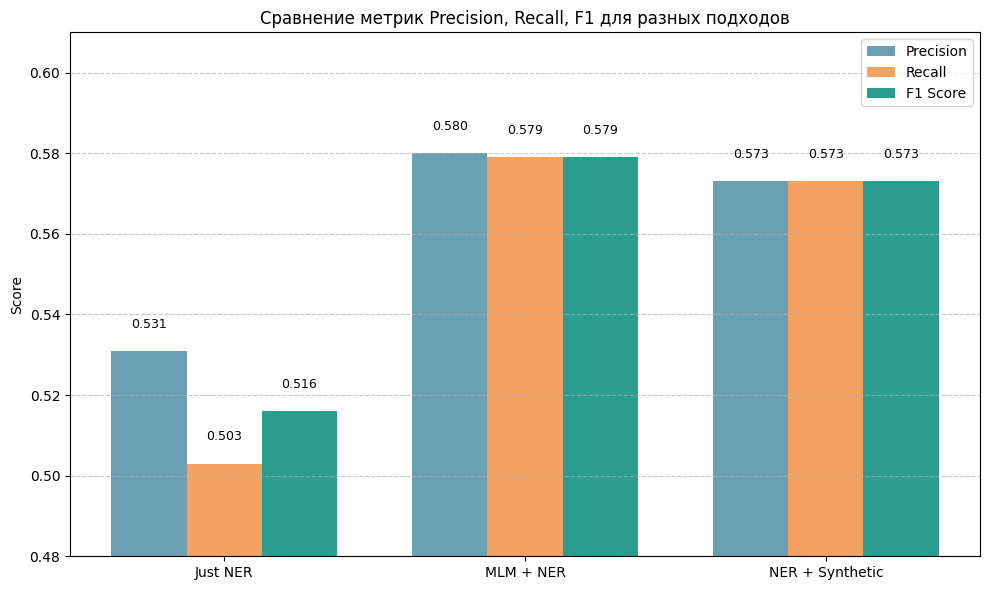

In [59]:
methods = ["Just NER", "MLM + NER", "NER + Synthetic"]

# Метрики
f1_scores = [0.516, 0.579, 0.573]
precisions = [0.531, 0.580, 0.573]
recalls = [0.503, 0.579, 0.573]

x = np.arange(len(methods))  # позиция групп
width = 0.25

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width, precisions, width, label='Precision', color='#6a9fb5')
bars2 = plt.bar(x, recalls, width, label='Recall', color='#f4a261')
bars3 = plt.bar(x + width, f1_scores, width, label='F1 Score', color='#2a9d8f')

# Подписи
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom', fontsize=9)

plt.ylabel("Score")
plt.title("Сравнение метрик Precision, Recall, F1 для разных подходов")
plt.xticks(x, methods)
plt.ylim(0.48, 0.61)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Видно, что лучше всего получился результат у 2 способа с предварительным обучением для MLM задачи.